<hr>

# 🤖 MACHINE LEARNING 🤖

<style>
h1 {
    text-align: center;
    color: hotpink;
    font-weight: bold;
}
</style>

<style>
h2 {
    text-align: center;
    color: black;
    font-weight: bold;
}
</style>

<style>
h3 {
    text-align: center;
    color: black;
    font-weight: bold;
}
</style>

<style>
h4 {
    text-align: center;
    color: black;
    font-weight: bold;
}
</style>

<hr>

In [1]:
!pip install xgboost

In [2]:
import pandas as pd
from sklearn.metrics import accuracy_score  
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, average_precision_score
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
import numpy as np


In [3]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test  = pd.read_csv("../data/processed/y_test.csv").values.ravel()

# XGBoost model

## Scale POS weight  - XGBoost

In [4]:
neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)
base_spw = neg / pos

print("neg:", neg, "pos:", pos, "base scale_pos_weight:", base_spw)

neg: 8338 pos: 1526 base scale_pos_weight: 5.463958060288335


## PR curve for optimal SPW = 3

PR AUC (Test): 0.741274321156746


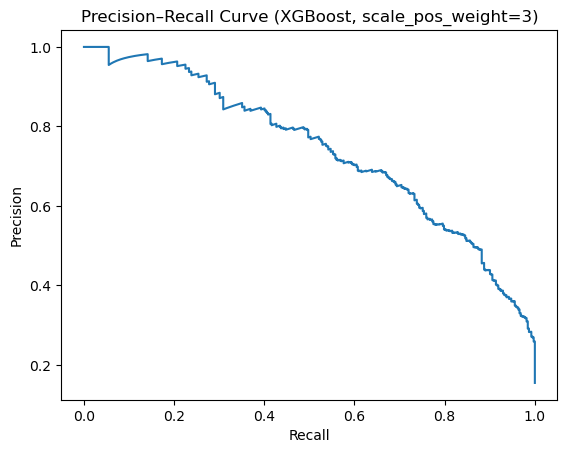

In [5]:
# XGBoost with scale_pos_weight = 3
xgb_spw3 = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=3,
    random_state=42,
    eval_metric="logloss"
)

xgb_spw3.fit(X_train, y_train)

# Predicted probabilities on TEST set
y_test_proba_spw3 = xgb_spw3.predict_proba(X_test)[:, 1]

# Precision-Recall curve points
precision, recall, thresholds = precision_recall_curve(y_test, y_test_proba_spw3)

# PR AUC (Average Precision)
pr_auc = average_precision_score(y_test, y_test_proba_spw3)
print("PR AUC (Test):", pr_auc)

# Plot PR curve
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (XGBoost, scale_pos_weight=3)")
plt.show()

## Probability Threshold Adjustments

In [6]:
#PR threshold
precision, recall, thresholds = precision_recall_curve(y_test, y_test_proba_spw3)

#creating a table of thresholds, precision, and recall
pr_df = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1]
})

pr_df.head(10)

,threshold,precision,recall
0,0.000482,0.154907,1.0
1,0.000576,0.154970,1.0
2,0.000584,0.155032,1.0
3,0.000671,0.155095,1.0
4,0.000715,0.155158,1.0
5,0.000771,0.155221,1.0
6,0.000779,0.155285,1.0
7,0.000866,0.155348,1.0
8,0.000893,0.155411,1.0
9,0.000900,0.155474,1.0


## Best F1

In [7]:
pr_df["f1"] = 2 * (pr_df["precision"] * pr_df["recall"]) / (pr_df["precision"] + pr_df["recall"])
pr_df.loc[pr_df["f1"].idxmax()]

threshold    0.576681
precision    0.643192
recall       0.717277
f1           0.678218
Name: 2028, dtype: float64

Business Interpretation:

- Nudges like Discount codes (10–20% off), Cashback offers, Free shipping, Personalized coupon campaigns, limited time deals on price are expensive, so we'll have to strike a balance between the recall and precision

- Recall  = 0.72 means we capture 72% of all converters

- Precision = 0.64 means of customers we target, 64% convert, 36% nudges go to non-converters ~ this means a controlled marketing budget expenditure